# Titanic Data Analysis using Python

## Data Science Internship – Task 2

### Objective
Analyze the Titanic dataset to understand survival patterns based on gender, passenger class, and age group using Python libraries like Pandas, Seaborn, and Matplotlib.

# Import Required Libraries

In this step, we import the necessary Python libraries for:
- Data handling → Pandas
- Data visualization → Seaborn and Matplotlib

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic Dataset

The Titanic dataset is loaded using Pandas.
This dataset contains passenger information such as:
- Age
- Gender
- Passenger Class
- Survival Status

In [5]:
df = pd.read_csv("train.csv")

# Preview the Dataset

Display the first few rows of the dataset to understand its structure and columns.

In [6]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# Dataset Information

Check:
- Total rows and columns
- Data types
- Missing values

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# Check Missing Values

Identify columns that contain missing or null values.

In [8]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Data Cleaning

Handle missing values in the dataset:
- Fill missing Age values using median
- Fill missing Embarked values using mode
- Drop Cabin column due to excessive missing data

In [21]:
df["Age"] = df["Age"].fillna(df["Age"].median())


In [22]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [11]:
df.drop("Cabin", axis=1, inplace=True)

# Verify Cleaned Data

Recheck missing values after cleaning.

In [12]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Survival Analysis by Gender

Analyze whether males or females survived more.

In [13]:
survival_gender = df.groupby("Sex")["Survived"].mean()
print(survival_gender)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


# Visualization: Survival Rate by Gender

This bar chart shows survival rates of males and females.

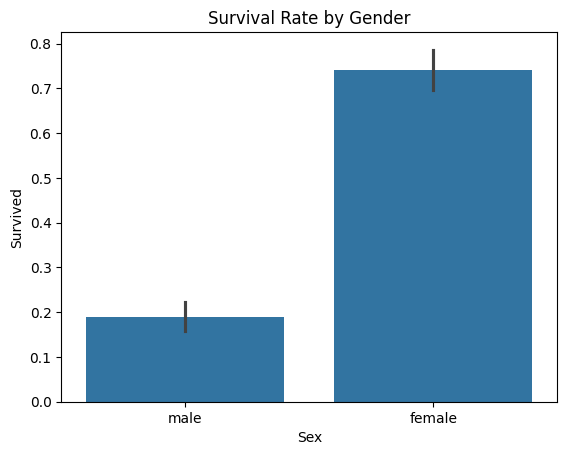

In [14]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()

# Survival Analysis by Passenger Class

Analyze whether passenger class affected survival chances.

In [15]:
survival_class = df.groupby("Pclass")["Survived"].mean()
print(survival_class)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


# Visualization: Survival Rate by Passenger Class

This chart compares survival rates across passenger classes.

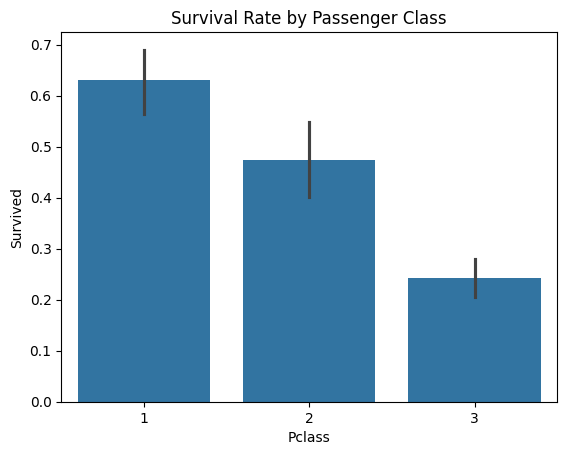

In [16]:
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

# Distribution of Passenger Ages

Visualize the age distribution of passengers using a histogram.

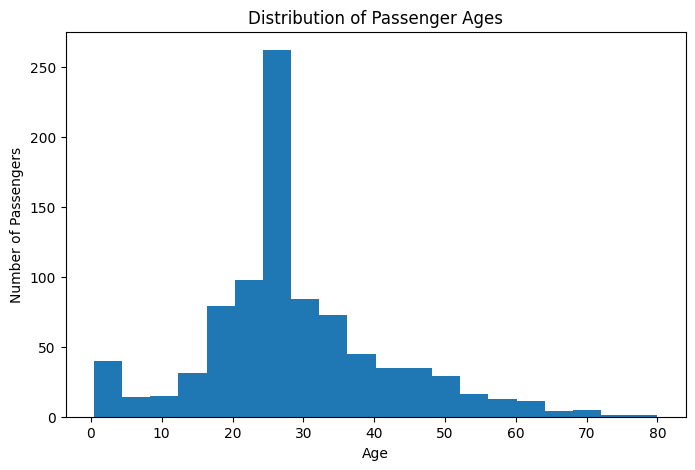

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

# Create Age Groups

Passengers are divided into:
- Child
- Teen
- Young Adult
- Adult
- Senior

In [18]:
bins = [0, 12, 19, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Survival Rate by Age Group

Analyze survival rates across different age groups.

In [19]:
age_survival = df.groupby("AgeGroup")["Survived"].mean()
print(age_survival)

AgeGroup
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_3412/3256121588.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


# Visualization: Survival Rate by Age Group

This chart shows which age group had better survival chances.

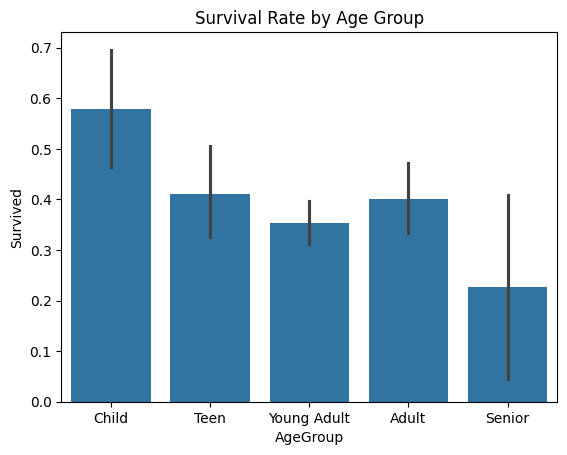

In [20]:
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival Rate by Age Group")
plt.show()

Conclusion:

1. Females had a higher survival rate than males.
2. First-class passengers survived more compared to lower classes.
3. Young adults and adults had better survival rates.
4. Data visualization helped identify important survival patterns.